## Implémentation actor-critic offline version conservative appliqué au data center (CQL(H)): 

In [489]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf
from tqdm import tqdm
from typing import Tuple, List

In [531]:
data = pd.read_csv("data_0425_0326.csv")

# Préparation du data set d'entrainement 
data["pue"] = data["GeneralPuissance"]/(data["OnduleurPuissance_1"] + data["OnduleurPuissance_2"])

data["mean_souff_1_1"] = (data["TemperatureSoufflage_1_1_1_105"] + data["TemperatureSoufflage_1_1_2_107"] + data["TemperatureSoufflage_1_1_3_109"])/3
data["mean_rep_1_1"] = (data["TemperatureReprise_1_1_1_106"] + data["TemperatureReprise_1_1_2_108"] + data["TemperatureReprise_1_1_3_110"])/3

data["mean_souff_1_2"] = (data["TemperatureSoufflage_1_2_1_205"] + data["TemperatureSoufflage_1_2_2_207"] + data["TemperatureSoufflage_1_2_3_209"])/3
data["mean_rep_1_2"] = (data["TemperatureReprise_1_2_1_206"] + data["TemperatureReprise_1_2_2_208"] + data["TemperatureReprise_1_2_3_210"])/3

data = data.iloc[1000:data.shape[0]-2000,:]

In [532]:
# Selection du data set action / état_t / rewards /  état_t+1 / 
X = (data[["OuvertureVanneFreecooling_1_1","OuvertureVanneCondenseur_1_1",
           'OuvertureVanneFreecooling_1_2', 'OuvertureVanneCondenseur_1_2',
          "Humide","Temperature","Vent","mean_souff_1_1","mean_rep_1_1",
          "mean_souff_1_2", "mean_rep_1_2",
          "GeneralPuissance","OnduleurPuissance_1","OnduleurPuissance_2",
          "pue","RotationVentilateur_1_1_1","RotationVentilateur_1_2_1"]]).copy()

X.OuvertureVanneFreecooling_1_1 = X.OuvertureVanneFreecooling_1_1/100
X.OuvertureVanneCondenseur_1_1 = X.OuvertureVanneCondenseur_1_1/100
X.OuvertureVanneFreecooling_1_2 = X.OuvertureVanneFreecooling_1_2/100
X.OuvertureVanneCondenseur_1_2 = X.OuvertureVanneCondenseur_1_2/100

# Récupéraration des commandes/actions 
X.loc[:,'a1_free'] = X['OuvertureVanneFreecooling_1_1']
X.loc[:,'a1_chill'] = X['OuvertureVanneCondenseur_1_1']
X.loc[:,"a1_vent"] = X["RotationVentilateur_1_1_1"]
X.loc[:,'a2_free'] = X['OuvertureVanneFreecooling_1_2']
X.loc[:,'a2_chill'] = X['OuvertureVanneCondenseur_1_2']
X.loc[:,"a2_vent"] = X["RotationVentilateur_1_2_1"]

# Récupération des états
X.loc[:,'s1'] = X['Temperature']
X.loc[:,'s2'] = X['mean_souff_1_1']
X.loc[:,'s3'] = X['mean_rep_1_1']
X.loc[:,'s4'] = X['mean_souff_1_2']
X.loc[:,'s5'] = X['mean_rep_1_2']
X.loc[:,'s6'] = X['GeneralPuissance']
X.loc[:,'s7'] = X['Humide']  
X.loc[:,'s8'] = X['OnduleurPuissance_1']
X.loc[:,'s9'] = X['OnduleurPuissance_2']
X.loc[:,"s10"] = X['pue']


# Récupération des états à t + 1
for i in range(1, 11):
    X.loc[:,f's{i}p1'] = X[f's{i}'].shift(-1)


# Création des rewards r(s,a,s')
X.loc[:,"r"] = (- 5*(np.maximum(0, X["s10p1"] - 1.25))**2  
- 2*(X["s2p1"] - 22.5)**2 - 2*(X["s4p1"] - 22.5)**2 
- 0.1*X["a1_chill"]**2  - 0.1*X["a2_chill"]**2
- 0.01*X["a1_free"]**2 - 0.01*X["a2_free"]**2
+ 0.5 * (X["s1p1"] < 18).astype(int) * X["a1_free"]
+ 0.5 * (X["s1p1"] < 18).astype(int) * X["a2_free"]
)


# Nettoyage des valeurs manquantes après shift 
X = X.dropna(subset=[f's{i}p1' for i in range(1, 11)])
X = X.dropna()


In [ ]:
def actor_NN(
    state_dim: int,
    action_dim: int,
    hidden_units=128
) -> tf.keras.Model:
    
    """
    (Actor dans un cas d'espace d'action continue)

    Fonction implémantant un réseau actor, afin d'approximer la politique paramétrisée ici par theta,
    où theta = (mu, sigma^2) les paramètres d'une loi normale multidimensionnel (en supossant que la matrice de covariance 
    est diagonale (attention : hyposthèse forte mais simplificatrice)).
    Ici, on considère log(sigma).

    state_dim : dimension de l'espace des états
    action_dim : dimension de l'esapce des actions
    hidden_units : nombre de neuronnes dans chaque couches cachés
    """

    inputs = tf.keras.layers.Input(shape=(state_dim,))
    
    # Couches cachées tanh (voire Kumar et al. 2020)
    x = tf.keras.layers.Dense(hidden_units, activation='tanh')(inputs)
    x = tf.keras.layers.Dense(hidden_units, activation='tanh')(x)
    
    # Couches de sorties
    mu = tf.keras.layers.Dense(action_dim, activation='linear')(x)
    log_sigma = tf.keras.layers.Dense(action_dim, activation='linear')(x)
    
    
    model = tf.keras.models.Model(inputs=inputs, outputs=[mu, log_sigma])
    
    return model

In [473]:
def critic_NN(
    state_dim: int,
    action_dim: int,
    hidden_units=256
) -> tf.keras.Model:

    """

    Fonction implémantant un réseau ciritc, afin d'approximer pour un couple état / action donné 
    la fonction Q-valeur paramétrisé par phi. 

    state_dim : dimension de l'espace des états
    action_dim : dimension de l'esapce des actions
    hidden_units : nombre de neuronnes dans chaque couches cachés
    """

    # Entrée séparée pour l'état et l'action
    state_input = tf.keras.Input(shape=(state_dim,))
    action_input = tf.keras.Input(shape=(action_dim,))

    concat = tf.keras.layers.Concatenate()([state_input, action_input])

    # Couches cachées (relu)
    x = tf.keras.layers.Dense(hidden_units, activation='relu')(concat)
    x = tf.keras.layers.Dense(hidden_units, activation='relu')(x)

    # Couche de sortie
    q_value = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs=[state_input, action_input], outputs=q_value)

    return model

In [ ]:
def sample_action_sto(
        actor : tf.keras.Model,
        state : np.array
) -> tf.Tensor:

        """
        Fonction qui tire un action d'une politique pi(.|s) avec paramétrisation pour gaussienne et sigmoid
        provenant du réseau NN actor. Conçu pour renvoyer une action dans [0,1].

        actor : réseau NN actor
        state : vecteur d'état
        """
        state = tf.cast(state, tf.float32)

        mu, log_sigma = actor(state)
        
        sigma = tf.exp(log_sigma)

        epsilon = tf.random.normal(shape=tf.shape(mu))

        z = mu + sigma * epsilon

        # Approximation avec sigmoid de l'action tirée
        a = tf.sigmoid(z) 

        return a

In [ ]:
def sample_action_det(
        actor : tf.keras.Model,
        state : np.array
)-> tf.Tensor:

        """
        Fonction qui tire un action d'une politique pi(.|s) avec paramétrisation pour gaussienne 
        provenant du réseau NN actor. Conçu pour renvoyer une action dans [0,1].
        Version déterministe où l'action tiré correspond à la moyenne des actions sous pi(a|s).

        actor : réseau NN actor
        state : vecteur d'état
        """
        state = tf.cast(state, tf.float32)

        mu, _ = actor(state)

        # Approximation avec sigmoid de l'action tirée
        a = tf.sigmoid(mu) 

        return a

In [ ]:
def log_prob(
        mu : tf.Tensor,
        log_sigma : tf.Tensor,
        z : tf.Tensor,
        actions : tf.Tensor
) -> tf.Tensor:

        """
        Fonction calculant log(pi(a|s)) dans le cas d'une politique dont la densité est paramétrisée
        par une fonction de type sigmoid(normal).

        mu : tenseur des moyennes donné par actor
        log_sigma : tenseur des log(sigma) donné par actor
        z : z = mu + sigma*eps où eps suit une N(0,1)
        actions : actions tiré selon sample_action_sto
        """

        sigma = tf.exp(log_sigma)
        var = sigma ** 2

        # log N(z | mu, sigma)
        logp = -0.5 * tf.reduce_sum(((z - mu) ** 2) / var, axis=1)
        logp -= tf.reduce_sum(log_sigma, axis=1)
        logp -= 0.5 * tf.cast(tf.shape(z)[1], tf.float32) * tf.math.log(2 * np.pi)

        # Prise en compte du changement de variable induit par sigmoid 
        logp -= tf.reduce_sum(tf.math.log(actions * (1 - actions) + 1e-6), axis=1)

        return logp

In [484]:
def train_actor(
        actor : tf.keras.Model,
        critic : tf.keras.Model,
        optimizer : tf.keras.optimizers,
        states : tf.Tensor,
        log_prob_fn = log_prob
)-> tf.Tensor:
    
    """
    Fonction implémentant une descente de gradient pour l'entrainement du réseau actor.
    Cette implémentation rentre dans le cadre d'un actor-critic basique reprenant "Offline Reinforcement Learning: Tutorial, Review,
    and Perspectives on Open Problems", Levine et al., nov 2020.
    Adapté dans le cadre d'une poltique paramétrisé par une densité sigmoid(normal).

    actor : réseau actor
    critic : réseau critic
    optimizer : optimizer keras 
    states : tenseur des états
    log_prob_fn : fonction log_prob par défaut, à modifier si autre paramétrisation de la politique souhaité
    """

    # Opérations enregistrées dans le graph de différenciation auto
    with tf.GradientTape() as tape:

        states = tf.cast(states, tf.float32)

        # Tirage d'actions selon l'actor
        mu, log_sigma = actor(states)
        sigma = tf.exp(log_sigma)
        eps = tf.random.normal(tf.shape(mu))
        z = mu + sigma * eps
        actions = tf.sigmoid(z)

        # Récupération des log(pi(a|s))
        logp = log_prob_fn(mu, log_sigma, z, actions)

        # Récupération des q valeurs selon critic
        q_sa = critic([states, actions])

        # Avantage avec baseline approximant E[Q(s,a)]
        advantage = q_sa - tf.stop_gradient(tf.reduce_mean(q_sa))

        # Loss finale à minimiser (ie. maximiser - loss)
        loss = - tf.reduce_mean(logp * advantage)

    # Descente de gradient pour l'actor
    grads = tape.gradient(loss, actor.trainable_variables)
    optimizer.apply_gradients(zip(grads, actor.trainable_variables))

    return loss

In [ ]:
def train_critic(
        critic : tf.keras.Model,
        critic_target : tf.keras.Model,
        actor : tf.keras.Model,
        optimizer : tf.keras.optimizers,
        states : tf.Tensor,
        actions : tf.Tensor,
        rewards : tf.Tensor,
        next_states : tf.Tensor,
        gamma : float,
        alpha : float,
        num_samples=10
    ) -> tf.Tensor :
    
    """
    Fonction implémentant une descente de gradient pour l'entrainement du réseau actor.
    Cette implémentation rentre dans le cadre d'un actor-critic CQL(H), sans paramètre de Lagrange pour le choix d'alpha automatique.
    Il reprend le pseudo-code fournit par Kumar et al., 2020 (Conservative Q-learning) pour un espace d'action continue.
    Adapté dans le cadre d'une poltique paramétrisé par une densité sigmoid(normal).

    critic : réseau critic
    critic target: réseau critic target
    actor : réseau actor
    optimizer : optimizer keras 
    states : tenseur des états
    actions : tenseur des actions 
    rewards : tenseur des rewards
    next_states : tenseurs des états t+1
    gamma : facteur d'escompte
    alpha : facteur "conservative" -> 0 = actor-critic naif offline, > 0 = CQL(H) actor-critic
    num_samples : nombre d'actions selectionnée uniformément pour le calcul de logsumexp(Q(s,a)) dans CQL(H)
    (voire annexe F, Kumar et al., 2020 )
    """
    
    # Mise en tenseur par précaution
    states = tf.cast(states, tf.float32)
    actions = tf.cast(actions, tf.float32)
    next_states = tf.cast(next_states, tf.float32)
    rewards = tf.cast(rewards, tf.float32)
    
    
    batch_size = 256
    action_dim = int(tf.shape(actions)[1].numpy())
    K = num_samples

    # Opérations enregistrées dans le graph de différenciation auto
    with tf.GradientTape() as tape:

        # Perte TD classique type actor-critic 
        q_current = critic([states, actions])
        next_actions = sample_action_sto(actor, next_states)
        q_next = critic_target([next_states, next_actions])
        target = rewards + gamma * tf.stop_gradient(q_next)
        td_loss = tf.reduce_mean(tf.square(q_current - target))

        # CQL(H) avec mélange type annexe F, Kumar et al.
        # Échantillons uniformes pour calcul de logsumexp(Q(s,a)) partie 1
        uniform_actions = tf.random.uniform((batch_size * K, action_dim), 0.0, 1.0, dtype=tf.float32)
       
        # Échantillons de l'acteur pour calcul de logsumexp(Q(s,a)) partie 1
        mu, log_sigma = actor(tf.tile(states, [K, 1]))
        sigma = tf.exp(tf.clip_by_value(log_sigma, -20, 2))
        eps = tf.random.normal(tf.shape(mu))
        z = mu + sigma * eps
        actor_actions = tf.sigmoid(z) 

        # Calcul de la densité pi(a|s) pour chaque action échantillonnée
        log_pi = log_prob(mu, log_sigma, z, actor_actions)        
        pi_density = tf.exp(log_pi)                               
        pi_density = tf.clip_by_value(pi_density, 1e-8, 1e8)

        all_actions = tf.concat([uniform_actions, actor_actions], axis=0)  
        states_tiled = tf.tile(states, [2*K, 1])                           

        # Q valeurs pour tous les échantillons
        q_all = critic([states_tiled, all_actions])                       
        q_all = tf.reshape(q_all, (2*K, batch_size))                        

    
        uniform_weights_tensor = tf.ones((K, batch_size), dtype=tf.float32)
        actor_weights_tensor = tf.reshape(1.0 / pi_density, (K, batch_size))
        all_weights = tf.concat([uniform_weights_tensor, actor_weights_tensor], axis=0)  # (2K, B)

        weighted_exp = all_weights * tf.exp(q_all)                
        sum_weighted_exp = tf.reduce_sum(weighted_exp, axis=0)    
        log_mean_exp = tf.math.log(sum_weighted_exp + 1e-10) - tf.math.log(tf.cast(2*K, tf.float32))

        # Moyenne sur le batch et perte CQL(H)
        log_mean_exp = tf.reduce_mean(log_mean_exp)
        mean_q_data = tf.reduce_mean(q_current)
        cql_loss = log_mean_exp - mean_q_data


        mean_q_data = tf.reduce_mean(q_current)
        cql_loss = log_mean_exp - mean_q_data

        loss = 0.5*td_loss + alpha * cql_loss

    # Descente de gradient
    grads = tape.gradient(loss, critic.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer.apply_gradients(zip(grads, critic.trainable_variables))
    
    return loss

In [486]:
def soft_update(
        critic : tf.keras.Model,
        critic_target : tf.keras.Model,
        tau=0.005
):
    """
    Fonction permettant de mettre à jour le réseau critic target de manière soft (voire Soft Actor-Critic:
    Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor, Haarnoja et al.)

    critic : réseau critic
    critic_target : réseau critic target
    tau : facteur soft 
    """

    for t, o in zip(critic_target.trainable_variables, critic.trainable_variables):
        t.assign(tau * o + (1 - tau) * t)

In [533]:
def AC_offline_CQLH(action_t : pd.DataFrame,
        state_t : pd.DataFrame,
        reward : np.array,
        state_tp1 : pd.DataFrame,
        nb_iteration : int,
        lr_actor : float,
        lr_critic : float,
        GQ : int,
        Gpi : int,
        gamma : float,
        alpha : float
) -> Tuple[tf.keras.Model, tf.keras.Model, List, List]: 
    
        """
        Fonction implémentant l'algorithme actor-critic (basique, ie. pas soft actor-critic)
        dans un cadre offline conservative (Kumar et al, Conservative Q-Learning
        for Offline Reinforcement Learning) version CQL(H) adapté pour espace d'action continue.
        Politique dont la densité est paramétrisée par sigmoid(normal).

        Pour information pour le correcteur ou Kapsdata : 
        En annexe F de Kumar et al, il est conseillé : 
                alpha dans [1,5] si pas d'optimisation Lagrangienne de alpha 
                nb_iteration = 1000 - 2000
                lr_actor = 3e-5
                lr_critic = 3e-4
        
        En général, il est conseillé dans un actor-critic de régler :
                GQ = 1 - 5 - 10
                Qpi = 1 - 2
        
        action_t : df actions du data set utilisé 
        state_t : df états courants du data set utilisé
        reward : df reward préalablement calculé 
        state_tp1 : df états t+1 du data set utilisé
        nb_iteration : nombre d'étape de gradient
        lr_actor : learning rate pour le réseau actor 
        lr_critic : learning rate pour le réseau critic
        GQ : nomhre d'étape d'actualisation de theta (critic)
        Gpi : nomhre d'étape d'actualisation de phi (actor)
        gamma : facteur d'escompte
        alpha : facteur "conservative" -> 0 = actor-critic naif offline, > 0 = CQL(H)

        """
        # Récupération des dimensions
        state_dim = state_t.shape[1]
        action_dim = action_t.shape[1]

        # Conversion pandas vers numpy
        A = action_t.to_numpy()
        S = state_t.to_numpy()
        Sp1 = state_tp1.to_numpy()
        R = reward


        nb_obs = A.shape[0]
        n_batch = 256
        
        #Initialisation NN actor
        state_dim = state_t.shape[1]
        action_dim = action_t.shape[1]
        actor = actor_NN(state_dim=state_dim, action_dim=action_dim)

        #Initialisation NN critic et critic target
        critic = critic_NN(state_dim=state_dim, action_dim=action_dim)
        critic_target = critic_NN(state_dim=state_dim, action_dim=action_dim)
        critic_target.set_weights(critic.get_weights())

        optimizer_critic = tf.keras.optimizers.Adam(learning_rate=lr_critic)
        optimizer_actor = tf.keras.optimizers.Adam(learning_rate=lr_actor)

        loss_critic = list()
        loss_actor = list()

        for i in tqdm(range(nb_iteration)):
                
                # Entrainement critic 
                for g in range(0,GQ):
                        # Tirage aléatoire d'un mini-batch dans le data set
                        index =  np.random.randint(0, nb_obs, size= n_batch)
                        A_it = A[index,]
                        S_it = S[index,]
                        R_it = R[index]
                        Sp1_it = Sp1[index,]
                        
                        
                        loss_critic_it = (train_critic(
                        critic = critic, critic_target = critic_target, actor = actor,
                        optimizer = optimizer_critic, states = S_it, actions = A_it,
                        rewards = R_it, next_states = Sp1_it, gamma = gamma, alpha = alpha))

                
                        soft_update(critic=critic, critic_target=critic_target)

                loss_critic.append(loss_critic_it)

                # Entrainement actor 
                for g in range(0,Gpi):

                        # Tirage aléatoire d'un mini-batch dans le data set
                        index =  np.random.randint(0, nb_obs, size= n_batch)
                        S_it = S[index,]
                        
                        loss_actor_it = (train_actor(
                        actor = actor, critic = critic, optimizer = optimizer_actor,
                        states = S_it, log_prob_fn = log_prob))

                loss_actor.append(loss_actor_it)

                
        return actor, critic, loss_actor, loss_critic


    

In [ ]:
# Récupération des transitions 
A_ = X[["a1_free","a1_chill"]]
St = X[[f"s{i}" for i in range(1,11)]]
Stp1 = X[[f"s{i}p1" for i in range(1,11)]]
R = X["r"].values.reshape(-1,1)

# Normalisation
mean_st = St.mean(axis=0)
std_st = St.std(axis=0)
mean_st1 = Stp1.mean(axis=0)
std_st1 = Stp1.std(axis=0)
mean_r = R.mean(axis=0)
std_r = R.std(axis=0)

St = (St - mean_st) / std_st
Stp1 = (Stp1 - mean_st1) / std_st1
R = (R - mean_r) / std_r



In [ ]:
# Entrainement offline
actor, critic, loss_actor, loss_critic = AC_offline_CQLH(A_, St, R, Stp1, 1000, 3e-5, 3e-4, 1, 1, gamma = 0.99, alpha = 5)

1.3969839e-09 -0.9574654
8.381903e-09 -0.760247
3.7252903e-09 -1.0028101
-2.7299393e-08 -1.023143
-1.1175871e-08 -1.3429931
1.7229468e-08 0.008574009
1.8626451e-08 -1.6294142
-2.0721927e-08 0.9447074
-1.6763806e-08 -1.8323622
3.259629e-08 -1.9729841
9.313226e-10 -1.681184
5.5413693e-08 -1.5947394
-3.4924597e-08 -2.0557902
4.7963113e-08 -2.2972662
1.5832484e-08 -2.2083993
-4.004687e-08 -2.7315953
1.1175871e-08 -2.4660578
-7.4505806e-08 0.38337612
-2.8871e-08 -2.9234433
3.9115548e-08 -3.009314
-6.9849193e-09 -3.1861284
-1.0244548e-08 -2.9193752
2.2584572e-08 -3.3992157
4.656613e-08 -3.4371293
-7.264316e-08 -3.6339126
-2.0256266e-08 0.16816759
2.9802322e-08 -3.7522373
2.7939677e-08 -3.7529416
1.2293458e-07 -3.544991
-2.7939677e-08 -3.913545
-3.1664968e-08 -4.1860256
4.656613e-08 -3.5784812
-5.401671e-08 -3.6712027
-2.7939677e-09 -4.513645
1.2526289e-07 -4.601491
3.259629e-08 -1.9005408
-3.7252903e-08 -4.815523
2.6077032e-08 -5.129242
2.514571e-08 -4.7306056
7.636845e-08 -5.4952617
-3.7252

In [527]:
loss_actor = [loss_actor[i].numpy() for i in range(len(loss_actor))]
loss_critic = [loss_critic[i].numpy() for i in range(len(loss_critic))]

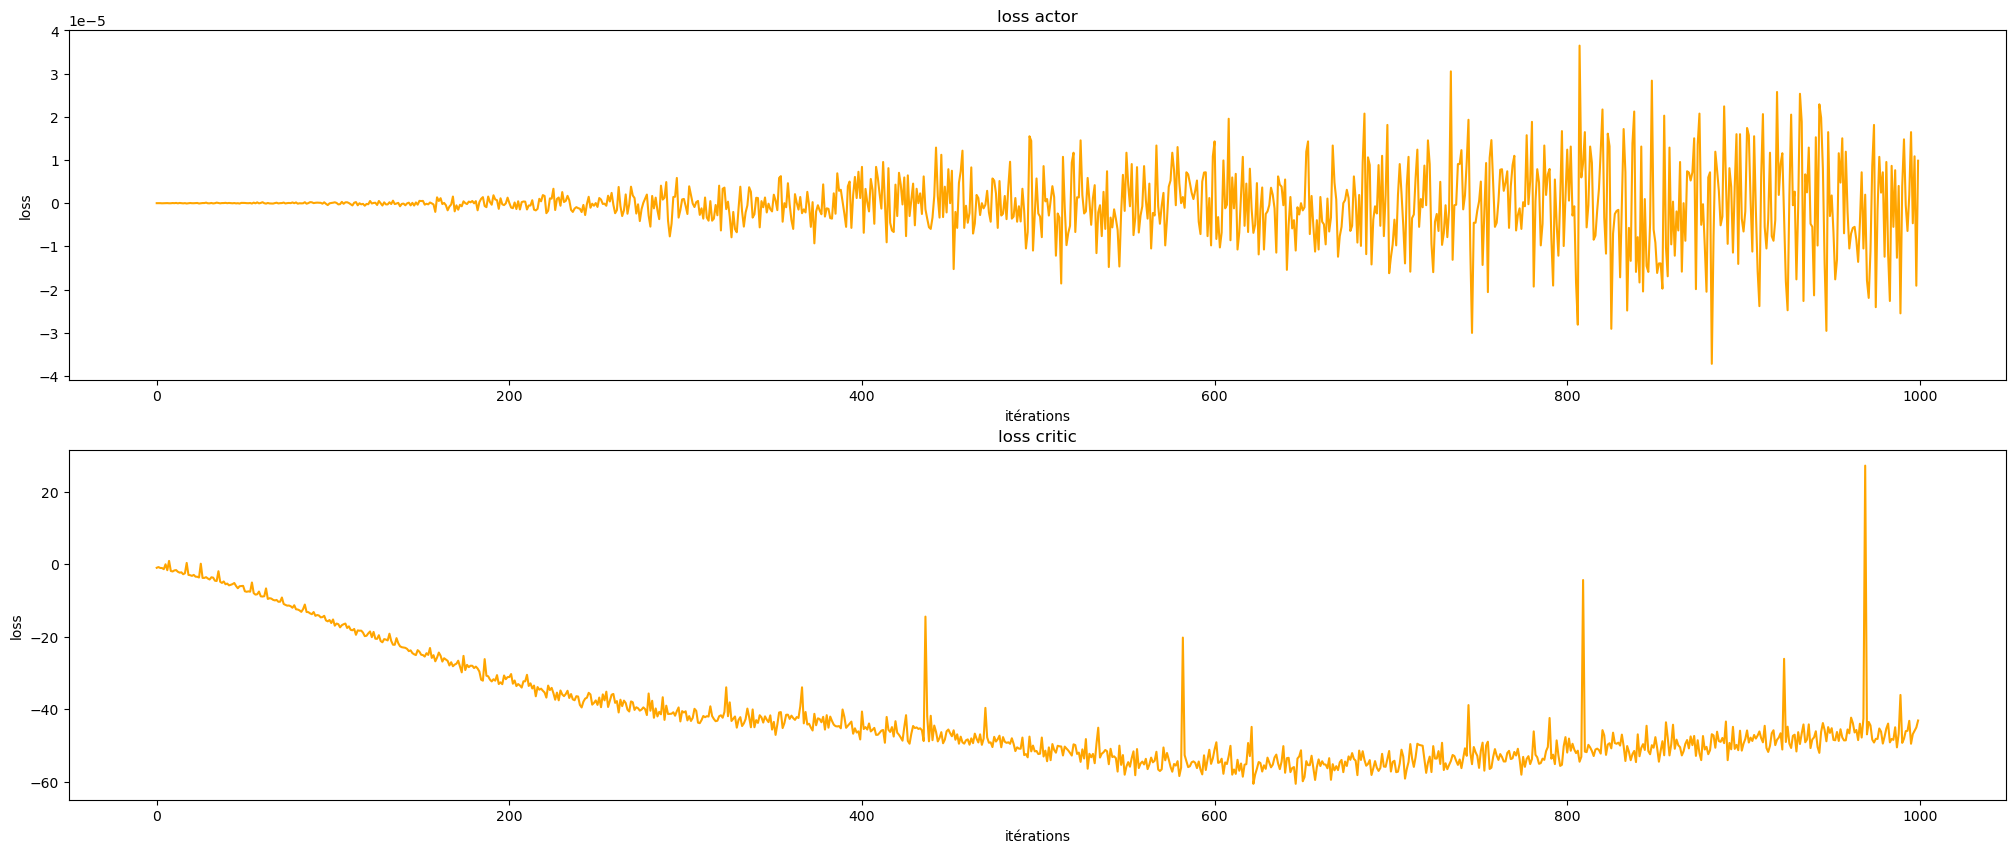

In [539]:
fig, ax = plt.subplots(2,1, figsize = (25,10))
ax[0].plot(range(len(loss_actor)), loss_actor, color = "orange")
ax[0].set_title("loss actor")
ax[0].set_xlabel("itérations")
ax[0].set_ylabel("loss")

ax[1].plot(range(len(loss_critic)), loss_critic, color = "orange")
ax[1].set_title("loss critic")
ax[1].set_xlabel("itérations")
ax[1].set_ylabel("loss")

plt.show()


In [ ]:
# Récupération des actions prises par l'algorithme sur le data set pour comparaison
St = St.to_numpy()
good_traj = np.ones((10000,2))

for i in tqdm(range(0,10000)):
    S_it = St[i,:]
    actions = sample_action_det(actor, S_it.reshape(1,-1)).numpy()
    good_traj[i,0] = actions[0][0]
    good_traj[i,1] = actions[0][1]

100%|██████████| 10000/10000 [00:47<00:00, 209.95it/s]


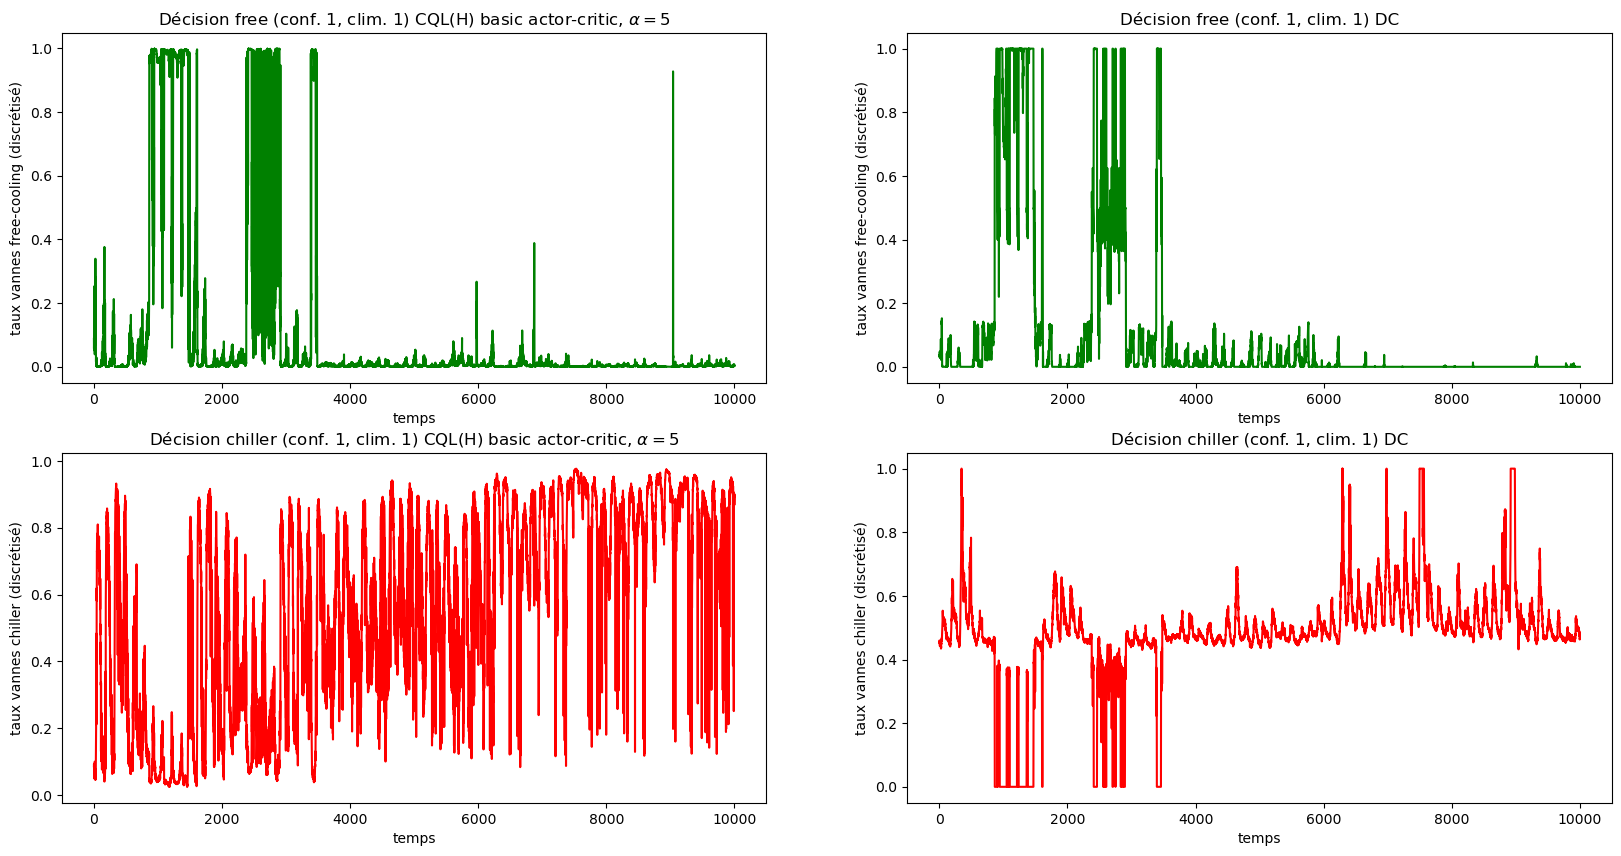

In [538]:
# VIsualisation graphique sur 1666 heures arbitraires pour comparaison DC -- actor-critic
fig, ax = plt.subplots(2,2,figsize=(20,10))

ax[0,0].plot(range(good_traj.shape[0]),good_traj[:,0], color = "green")
ax[0,0].set_title(r"Décision free (conf. 1, clim. 1) CQL(H) basic actor-critic, $\alpha = 5$")
ax[0,0].set_xlabel("temps")
ax[0,0].set_ylabel("taux vannes free-cooling (discrétisé)")

ax[1,0].plot(range(good_traj.shape[0]),good_traj[:,1], color = "red")
ax[1,0].set_title(r"Décision chiller (conf. 1, clim. 1) CQL(H) basic actor-critic, $\alpha = 5$")
ax[1,0].set_xlabel("temps")
ax[1,0].set_ylabel("taux vannes chiller (discrétisé)")


ax[0,1].plot(range(good_traj.shape[0]),A_.iloc[:10000,0], color = "green")
ax[0,1].set_title("Décision free (conf. 1, clim. 1) DC")
ax[0,1].set_xlabel("temps")
ax[0,1].set_ylabel("taux vannes free-cooling (discrétisé)")

ax[1,1].plot(range(good_traj.shape[0]),A_.iloc[:10000,1], color = "red")
ax[1,1].set_title("Décision chiller (conf. 1, clim. 1) DC")
ax[1,1].set_xlabel("temps")
ax[1,1].set_ylabel("taux vannes chiller (discrétisé)")


plt.show()
